<a href="https://colab.research.google.com/github/adljna/Blu-SentimentAnalysis/blob/main/ScrapReview_bluApp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install google_play_scraper
!pip install textblob
!pip install seaborn

from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

sns.set_theme()
plt.rcParams["figure.figsize"] = (15,10)

In [2]:
#Android App blu by BCA link from Google Play at
#https://play.google.com/store/apps/details?id=com.bcadigital.blu
#The apps ID found in the link after id=com.bcadigital.blu
#The apps name on Google Play titled: blu by BCA Digital
#Dated 2 March 2026 | Number of reviews: 113k

from google_play_scraper import app, Sort, reviews_all

blu_reviews = reviews_all(
    'com.bcadigital.blu',
    sleep_milliseconds=0, # defaults to 0
    lang='en', # defaults to 'en'
    sort=Sort.NEWEST, # defaults to Sort.MOST_RELEVANT
)

In [3]:
#Save the blu Apps reviews into dataframe
df_bluRev = pd.DataFrame(np.array(blu_reviews),columns=['content'])
df_bluRev = df_bluRev.join(pd.DataFrame(df_bluRev.pop('content').tolist()))
df_bluRev.to_csv(r'df_bluRev.csv', index=False)
df_bluRev.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,431ac010-f1fa-4d6a-98ec-6c8da9629a2f,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,nice apps dr blu 👍,5,0,None,2026-03-04 03:09:07,"Hai, Kak Arie Kurniawan. Terima kasih atas ula...",2026-03-04 04:06:33,None
1,f3127828-f41a-4174-b217-0bc54195d9b9,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Always ask permission for location eventhough ...,2,0,2.9.20,2026-03-04 00:03:04,"Hai, Kak Teddy. Maaf atas ketidaknyamanannya.B...",2026-03-04 00:17:16,2.9.20
2,193123c7-65d6-4736-bd20-dfa775022119,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,sering banget eror,3,0,2.9.20,2026-03-03 23:33:55,"Hai, Kak Zia. Maaf atas ketidaknyamanannya. Ka...",2026-03-04 00:17:01,2.9.20
3,740ae8f1-e797-4aed-ae05-bf687bf4dc70,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"buset loading loginnya lama bener ,mau bayar j...",1,0,2.9.20,2026-03-03 05:06:11,"Hai, Kak David Argoanto. Maaf atas ketidaknyam...",2026-03-03 06:29:11,2.9.20
4,c7a0f81b-a13c-4913-b0fa-276b36c6f2ce,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"face recognition nya jelek. gagal terus, udah ...",2,0,2.9.20,2026-03-03 02:52:27,"Hai, Kak Putri. Maaf atas ketidaknyamanannya. ...",2026-03-03 03:11:35,2.9.20


In [4]:
print(df_bluRev.reviewCreatedVersion.unique())
print(df_bluRev.reviewCreatedVersion.nunique())

[None '2.9.20' '2.9.10' '2.9.0' '1.48.10' '1.29.0' '2.8.10' '2.5.0'
 '2.8.0' '2.7.20' '1.67.0' '1.59.20' '1.42.10' '2.2.0' '1.63.10' '1.21.0'
 '2.7.10' '1.41.0' '2.7.0' '2.6.0' '1.27.0' '2.3.0' '2.4.0' '1.15.0'
 '2.1.10' '1.6.0' '1.61.0' '2.1.0' '2.0.20' '1.43.0' '2.0.30' '2.0.0'
 '2.0.10' '1.64.0' '1.66.0' '1.65.0' '1.60.0' '1.63.0' '1.62.10' '1.62.0'
 '1.55.0' '1.56.0' '1.57.20' '1.51.0' '1.54.0' '1.59.10' '1.59.0' '1.58.0'
 '1.57.10' '1.32.10' '1.57.0' '1.9.0' '1.53.10' '1.53.0' '1.52.10'
 '1.52.0' '1.50.0' '1.49.0' '1.47.0' '1.47.10' '1.46.0' '1.40.0' '1.33.0'
 '1.48.0' '1.45.0' '1.43.10' '1.34.0' '1.42.0' '1.31.0' '1.39.10'
 '1.35.10' '1.40.10' '1.10.0' '1.28.0' '1.36.0' '1.37.0' '1.39.0' '1.38.0'
 '1.13.0' '1.20.0' '1.5.0' '1.3.2' '1.30.0' '1.35.0' '1.32.0' '1.29.10'
 '1.28.10' '1.17.0' '1.14.0' '1.26.1' '1.26.0' '1.25.0' '1.16.0' '1.24.10'
 '1.22.0' '1.24.0' '1.23.0' '1.19.0' '1.18.0' '1.11.0' '1.12.0' '1.8.0'
 '1.7.0' '1.4.0' '1.3.3' '1.2.1']
105


In [5]:
#We do not need data for column reviewId, userName, userImage so we will show only these column
df_bluRev.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,nice apps dr blu 👍,5,0,None,2026-03-04 03:09:07,"Hai, Kak Arie Kurniawan. Terima kasih atas ula...",2026-03-04 04:06:33
1,Always ask permission for location eventhough ...,2,0,2.9.20,2026-03-04 00:03:04,"Hai, Kak Teddy. Maaf atas ketidaknyamanannya.B...",2026-03-04 00:17:16
2,sering banget eror,3,0,2.9.20,2026-03-03 23:33:55,"Hai, Kak Zia. Maaf atas ketidaknyamanannya. Ka...",2026-03-04 00:17:01
3,"buset loading loginnya lama bener ,mau bayar j...",1,0,2.9.20,2026-03-03 05:06:11,"Hai, Kak David Argoanto. Maaf atas ketidaknyam...",2026-03-03 06:29:11
4,"face recognition nya jelek. gagal terus, udah ...",2,0,2.9.20,2026-03-03 02:52:27,"Hai, Kak Putri. Maaf atas ketidaknyamanannya. ...",2026-03-03 03:11:35
...,...,...,...,...,...,...,...
7497,100 penginstall pertama,5,0,None,2021-07-02 03:28:59,"Hai, Kak Audrey Maximillian. Terima kasih atas...",2021-07-04 08:37:22
7498,amazing...fiturnya dan gratis transfer dan topup,5,3,None,2021-07-02 03:24:17,"Hai, Kak Andre Huang. Terima kasih atas ulasan...",2021-07-04 08:28:42
7499,Gak ada yang wah fiturnya biasa ajah sama kaya...,3,1,None,2021-07-02 03:19:59,"Hai, Kak dyla fadhilatun. Terima kasih untuk f...",2021-07-04 08:27:29
7500,"nitip, ntar review tan",5,1,1.3.2,2021-07-02 02:32:29,"Hai, Kak Yandra Prawinata. Terima kasih atas u...",2021-07-04 07:29:20


In [6]:
!pip install emoji

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", 200)
import regex
import nltk
import wordcloud

from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob

import string
import re
import emoji

In [7]:
#Creating polarity on the column: content (review from the apps) using TextBlob
#Read https://textblob.readthedocs.io/en/dev/quickstart.html

from textblob import TextBlob
df_bluRev['sentiment_polarity'] = df_bluRev['content'].apply(lambda x: TextBlob(x).polarity)
df_bluRev['sentiment_subjective'] = df_bluRev['content'].apply(lambda x: TextBlob(x).subjectivity)

In [8]:
#df_bluRev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","at"]]
df_bluRev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective"]]

,content,score,sentiment_polarity,sentiment_subjective
0,nice apps dr blu 👍,5,0.6,1.0
1,Always ask permission for location eventhough I already gave the permission. I use x9c honor. please repair.,2,0.0,0.0
2,sering banget eror,3,0.0,0.0
3,"buset loading loginnya lama bener ,mau bayar jadi sulit",1,0.0,0.0
4,"face recognition nya jelek. gagal terus, udah beberapa kali ganti device selalu ada masalah di login face recognition. kalau memang belum matang, lebih baik ada opsi lain untuk login. selain hubun...",2,0.0,0.0
...,...,...,...,...
7497,100 penginstall pertama,5,0.0,0.0
7498,amazing...fiturnya dan gratis transfer dan topup,5,0.0,0.0
7499,Gak ada yang wah fiturnya biasa ajah sama kaya samping. Gak ada yang membedakan.,3,0.0,0.0
7500,"nitip, ntar review tan",5,0.0,0.0


In [9]:
#Check number of reviews scores
df_bluRev['score'].value_counts()

,count
score,
5,3580
1,2134
3,616
4,593
2,579


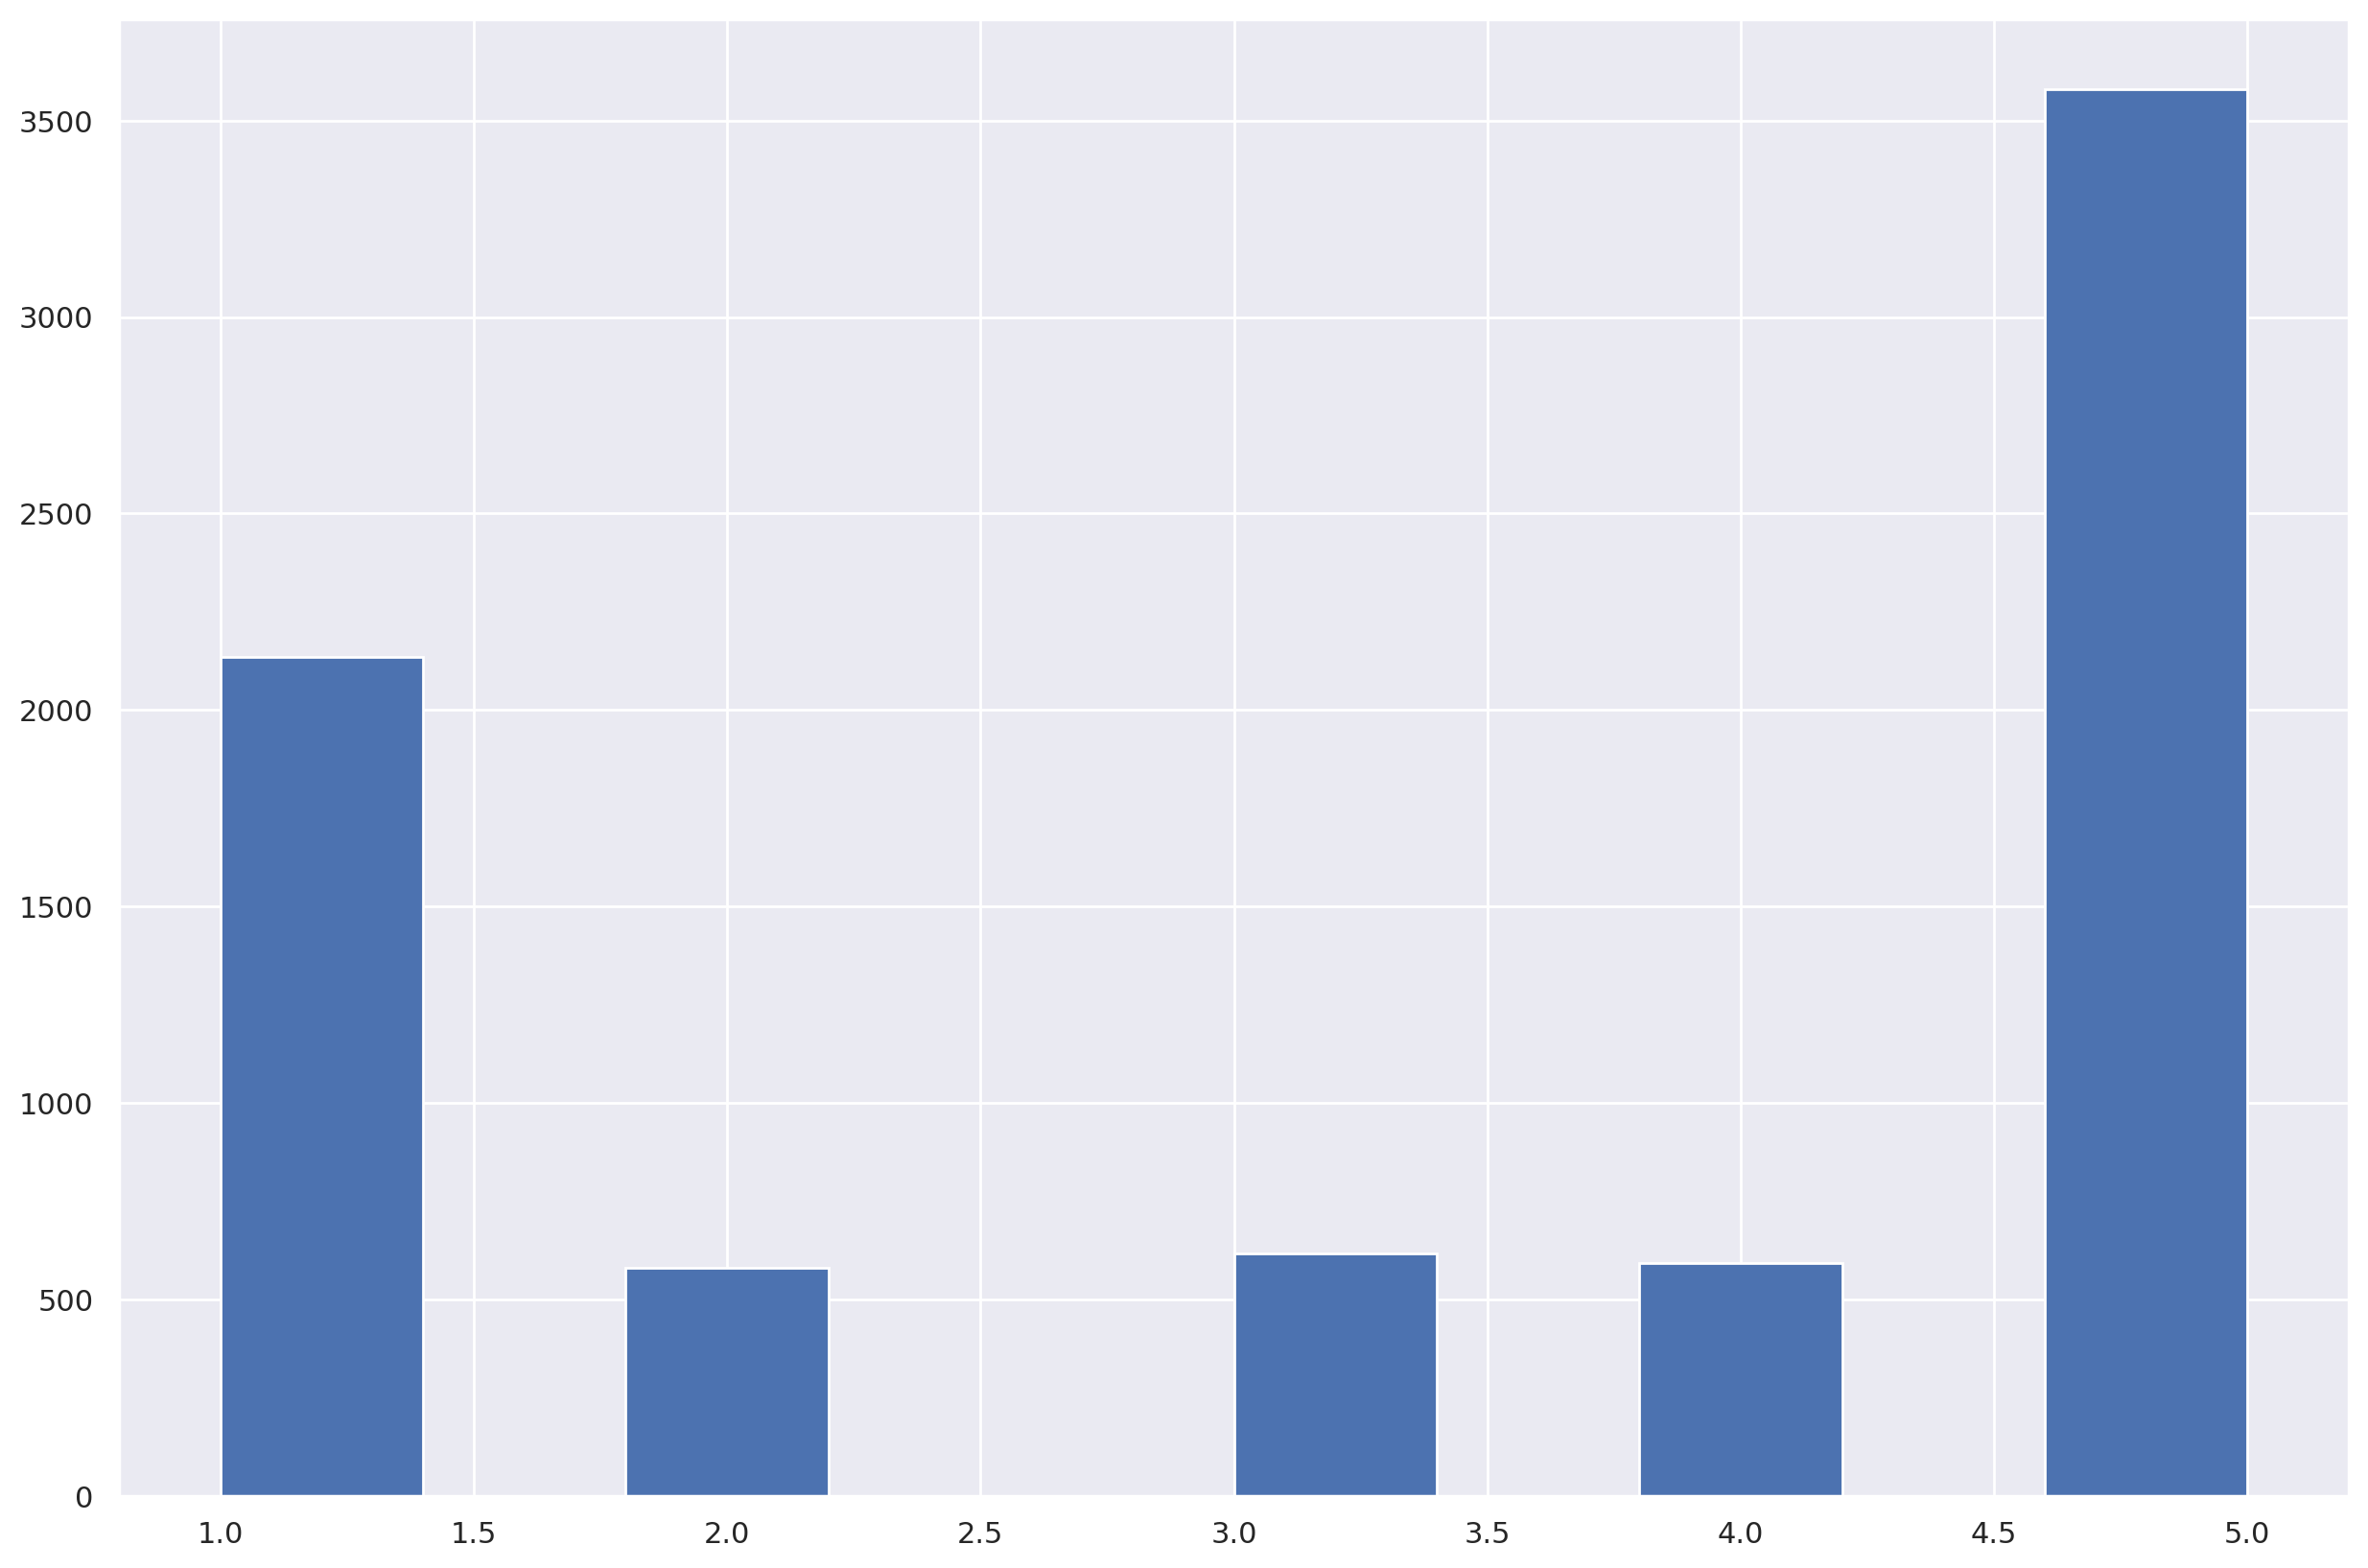

In [10]:
plt.hist(df_bluRev['score'])
plt.show()

In [11]:
#DATA PREPROCESSING

#Lower casing
#Change the reviews type to string
df_bluRev['content'] = df_bluRev['content'].astype(str)
#Before lowercasing
print(df_bluRev['content'][1])

Always ask permission for location eventhough I already gave the permission. I use x9c honor. please repair.


In [12]:
#Lowercase all reviews to see the difference
df_bluRev['content']= df_bluRev['content'].apply(lambda x: x.lower())
print(df_bluRev['content'][1])

always ask permission for location eventhough i already gave the permission. i use x9c honor. please repair.


In [13]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [14]:
#edited from https://www.tensorscience.com/nlp/sentiment-analysis-tutorial-in-python-classifying-reviews-on-movies-and-products
import string

df_bluRev['wordCount'] = [len(review.split()) for review in df_bluRev['content']]

df_bluRev['uppercaseCharCount'] = [sum(char.isupper() for char in review) \
                              for review in df_bluRev['content']]

df_bluRev['specialCharCount'] = [sum(char in string.punctuation for char in review) \
                            for review in df_bluRev['content']]

In [15]:
df_bluRev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","wordCount","uppercaseCharCount","specialCharCount"]]

,content,score,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount
0,nice apps dr blu 👍,5,0.6,1.0,5,0,0
1,always ask permission for location eventhough i already gave the permission. i use x9c honor. please repair.,2,0.0,0.0,17,0,3
2,sering banget eror,3,0.0,0.0,3,0,0
3,"buset loading loginnya lama bener ,mau bayar jadi sulit",1,0.0,0.0,9,0,1
4,"face recognition nya jelek. gagal terus, udah beberapa kali ganti device selalu ada masalah di login face recognition. kalau memang belum matang, lebih baik ada opsi lain untuk login. selain hubun...",2,0.0,0.0,35,0,5
...,...,...,...,...,...,...,...
7497,100 penginstall pertama,5,0.0,0.0,3,0,0
7498,amazing...fiturnya dan gratis transfer dan topup,5,0.0,0.0,6,0,3
7499,gak ada yang wah fiturnya biasa ajah sama kaya samping. gak ada yang membedakan.,3,0.0,0.0,14,0,2
7500,"nitip, ntar review tan",5,0.0,0.0,4,0,1


In [16]:
#Removing stopwords
#Using nltk
import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize, sent_tokenize
from nltk import FreqDist
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer
from nltk.stem.wordnet import WordNetLemmatizer


from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

from string import punctuation

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [17]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()

  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  ax = sns.barplot(data=d, x= "word", y = "count")
  ax.set(ylabel = 'Count')
  plt.show()

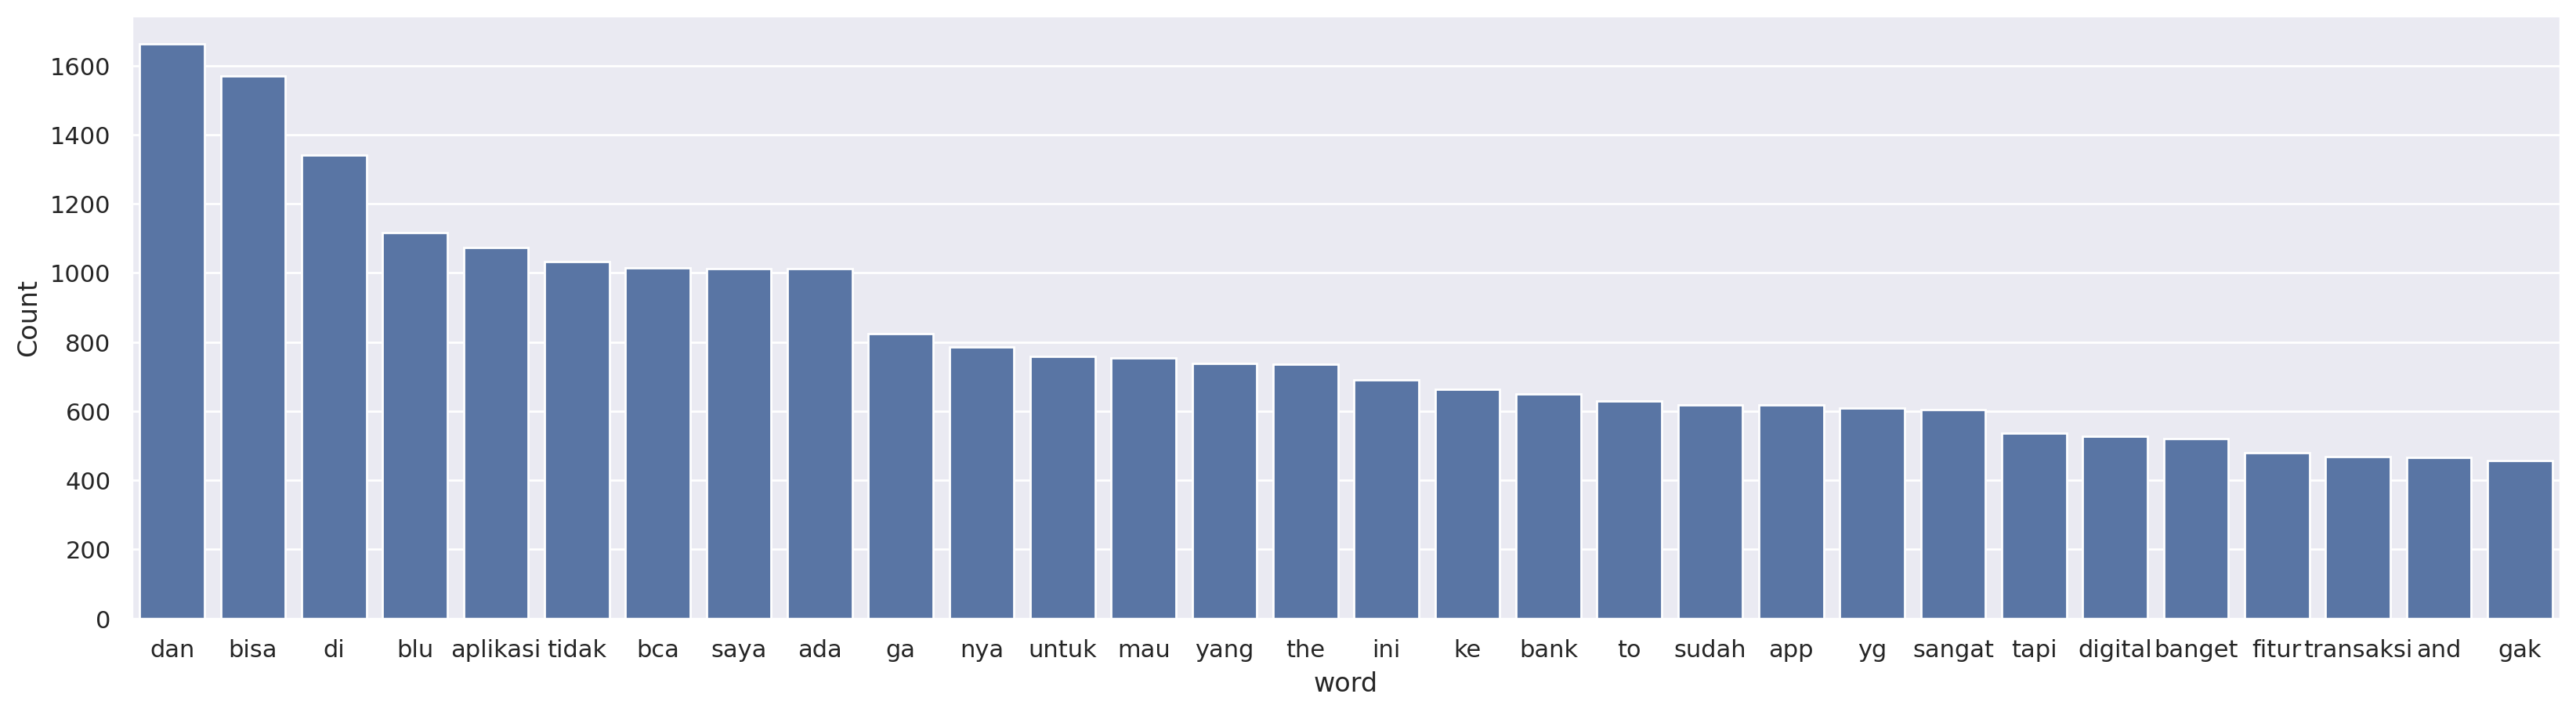

In [18]:
freq_words(df_bluRev['content'])

In [19]:
#check if there is any special character
alphabet = string.ascii_letters+string.punctuation
print(df_bluRev.content.str.strip(alphabet).astype(bool).any())

extracted_emojis=[]

def extract_emojis(s):
    expe = re.compile('[\U00010000-\U0010ffff]', flags=re.UNICODE)
    return expe.findall(s)
    return expe.sub(r'',s)

for y in df_bluRev['content']:
    #print(str(extract_emojis(y)))
    extracted_emojis.append(str(extract_emojis(y)))

print(extracted_emojis)

True
["['👍']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['🥲']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['😑']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['😪', '😪', '😪', '😪']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['🗿']", '[]', "['😭', '😭']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['👍']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['🤧']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['👎', '🏼', '👎', '🏼', '👎', '🏼']", "['👍', '🏻']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['😭', '😔']", '[]', '[]', '[]', "['😍', '🫰', '🏼']", '[]', '[]', '[]', '[]', '[]', '[]', "['😔']", '[]', '[]', '[]', "['🤦']", '[]', '[]',

In [20]:
df_bluRev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","wordCount","uppercaseCharCount","specialCharCount"]]

,content,score,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount
0,nice apps dr blu 👍,5,0.6,1.0,5,0,0
1,always ask permission for location eventhough i already gave the permission. i use x9c honor. please repair.,2,0.0,0.0,17,0,3
2,sering banget eror,3,0.0,0.0,3,0,0
3,"buset loading loginnya lama bener ,mau bayar jadi sulit",1,0.0,0.0,9,0,1
4,"face recognition nya jelek. gagal terus, udah beberapa kali ganti device selalu ada masalah di login face recognition. kalau memang belum matang, lebih baik ada opsi lain untuk login. selain hubun...",2,0.0,0.0,35,0,5
...,...,...,...,...,...,...,...
7497,100 penginstall pertama,5,0.0,0.0,3,0,0
7498,amazing...fiturnya dan gratis transfer dan topup,5,0.0,0.0,6,0,3
7499,gak ada yang wah fiturnya biasa ajah sama kaya samping. gak ada yang membedakan.,3,0.0,0.0,14,0,2
7500,"nitip, ntar review tan",5,0.0,0.0,4,0,1


In [21]:
#Add a column name polarity_rating from changing the score of the review into 3 labels: Positive, Negative, Neutral
df_bluRev['sentiment_rating'] = df_bluRev['score'].apply(lambda x: 'Positive' if x > 3 else('Neutral' if x == 3  else 'Negative'))

In [22]:
df_bluRev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,nice apps dr blu 👍,5,0.6,1.0,Positive
1,always ask permission for location eventhough i already gave the permission. i use x9c honor. please repair.,2,0.0,0.0,Negative
2,sering banget eror,3,0.0,0.0,Neutral
3,"buset loading loginnya lama bener ,mau bayar jadi sulit",1,0.0,0.0,Negative
4,"face recognition nya jelek. gagal terus, udah beberapa kali ganti device selalu ada masalah di login face recognition. kalau memang belum matang, lebih baik ada opsi lain untuk login. selain hubun...",2,0.0,0.0,Negative
...,...,...,...,...,...
7497,100 penginstall pertama,5,0.0,0.0,Positive
7498,amazing...fiturnya dan gratis transfer dan topup,5,0.0,0.0,Positive
7499,gak ada yang wah fiturnya biasa ajah sama kaya samping. gak ada yang membedakan.,3,0.0,0.0,Neutral
7500,"nitip, ntar review tan",5,0.0,0.0,Positive


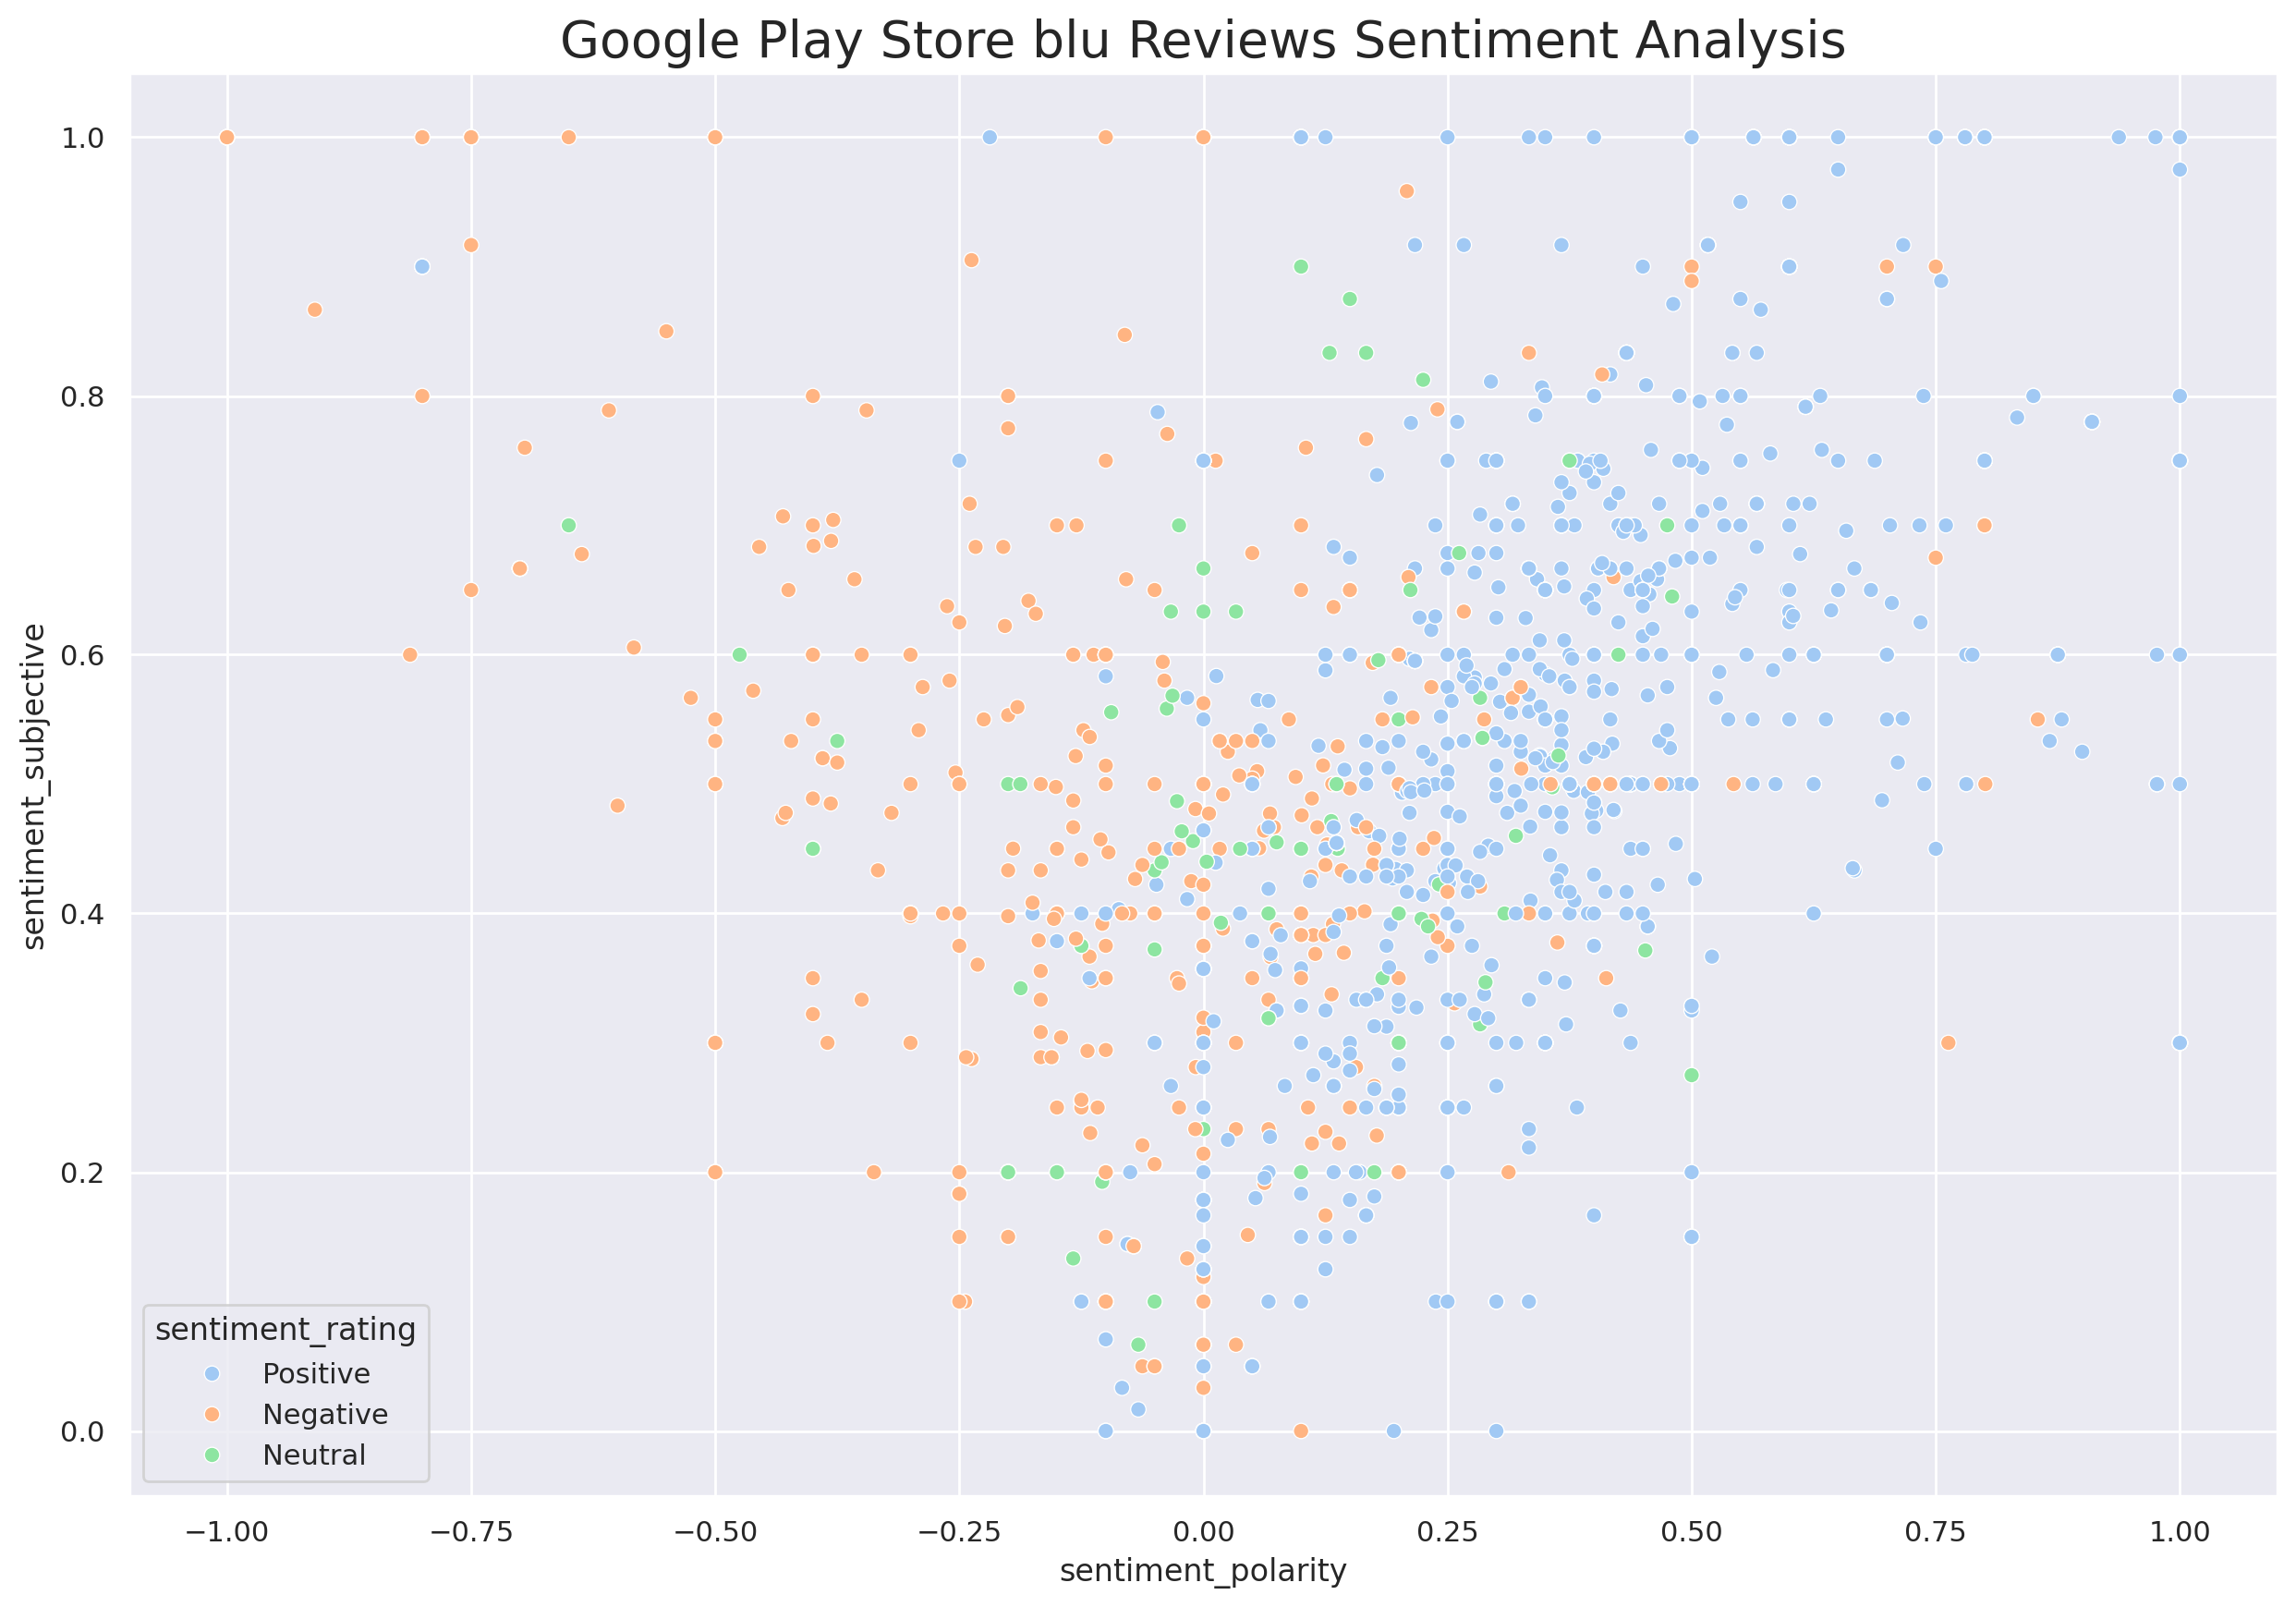

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 10))
sns.scatterplot(x=df_bluRev['sentiment_polarity'], y=df_bluRev['sentiment_subjective'],
                hue = df_bluRev['sentiment_rating'], edgecolor='white', palette="pastel")
plt.title("Google Play Store blu Reviews Sentiment Analysis", fontsize=20)
plt.show()

In [25]:
#Print the extracted emojis review column (content) before stopwords
df_bluRev.to_csv(r'df_bluRev_before_stopwords_sentiment_rating.csv', index = False)

In [65]:
import nltk
from nltk.corpus import stopwords

# Download Indonesian stopwords if not already downloaded
try:
    stopwords.words('indonesian')
except LookupError:
    nltk.download('stopwords')

stop = stopwords.words('english') + ["someone","still","and","would","need"]
stop.extend(stopwords.words('indonesian') + ["ga","gak","nya","aja","yg"])
print(stop)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [66]:
print(len(stop))

966


In [67]:
df_bluRev_stopwords = df_bluRev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

In [69]:
# Exclude stopwords
pat = r'\b(?:{})\b'.format('|'.join(stop))
df_bluRev_stopwords['review_without_stopwords'] = df_bluRev_stopwords['content'].str.replace(pat, '')
df_bluRev_stopwords['review_without_stopwords'] = df_bluRev_stopwords['review_without_stopwords'].str.replace(r'\s+', ' ')
df_bluRev_stopwords['review_without_stopwords'] = df_bluRev_stopwords['content'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))
print(df_bluRev_stopwords)

                                                                                                                                                                                                      content  \
0                                                                                                                                                                                          nice apps dr blu 👍   
1                                                                                                always ask permission for location eventhough i already gave the permission. i use x9c honor. please repair.   
2                                                                                                                                                                                          sering banget eror   
3                                                                                                                                                     buset loading 

In [70]:
#Save into csv after applying stopwords
df_bluRev_stopwords.to_csv(r'df_bluRev_after_stopwords_sentiment_rating.csv', index = False)

In [71]:
#Count after stopwords
#edited from https://www.tensorscience.com/nlp/sentiment-analysis-tutorial-in-python-classifying-reviews-on-movies-and-products
import string

df_bluRev_stopwords['wordCount'] = [len(review.split()) for review in df_bluRev_stopwords['content']]
df_bluRev_stopwords['wordCount_after_stopwords'] = [len(review.split()) for review in df_bluRev_stopwords['review_without_stopwords']]

In [72]:
df_bluRev_stopwords.loc[:,["content","score","sentiment_polarity", "sentiment_rating","wordCount","review_without_stopwords", "wordCount_after_stopwords"]]

,content,score,sentiment_polarity,sentiment_rating,wordCount,review_without_stopwords,wordCount_after_stopwords
0,nice apps dr blu 👍,5,0.6,Positive,5,nice apps dr blu 👍,5
1,always ask permission for location eventhough i already gave the permission. i use x9c honor. please repair.,2,0.0,Negative,17,always ask permission location eventhough already gave permission. use x9c honor. please repair.,13
2,sering banget eror,3,0.0,Neutral,3,banget eror,2
3,"buset loading loginnya lama bener ,mau bayar jadi sulit",1,0.0,Negative,9,"buset loading loginnya bener ,mau bayar sulit",7
4,"face recognition nya jelek. gagal terus, udah beberapa kali ganti device selalu ada masalah di login face recognition. kalau memang belum matang, lebih baik ada opsi lain untuk login. selain hubun...",2,0.0,Negative,35,"face recognition jelek. gagal terus, udah kali ganti device login face recognition. matang, opsi login. hubungi haloblu berbayar",18
...,...,...,...,...,...,...,...
7497,100 penginstall pertama,5,0.0,Positive,3,100 penginstall,2
7498,amazing...fiturnya dan gratis transfer dan topup,5,0.0,Positive,6,amazing...fiturnya gratis transfer topup,4
7499,gak ada yang wah fiturnya biasa ajah sama kaya samping. gak ada yang membedakan.,3,0.0,Neutral,14,fiturnya ajah kaya samping. membedakan.,5
7500,"nitip, ntar review tan",5,0.0,Positive,4,"nitip, ntar review tan",4


In [73]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()

  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  ax = sns.barplot(data=d, x= "word", y = "count")
  ax.set(ylabel = 'Count')
  plt.show()

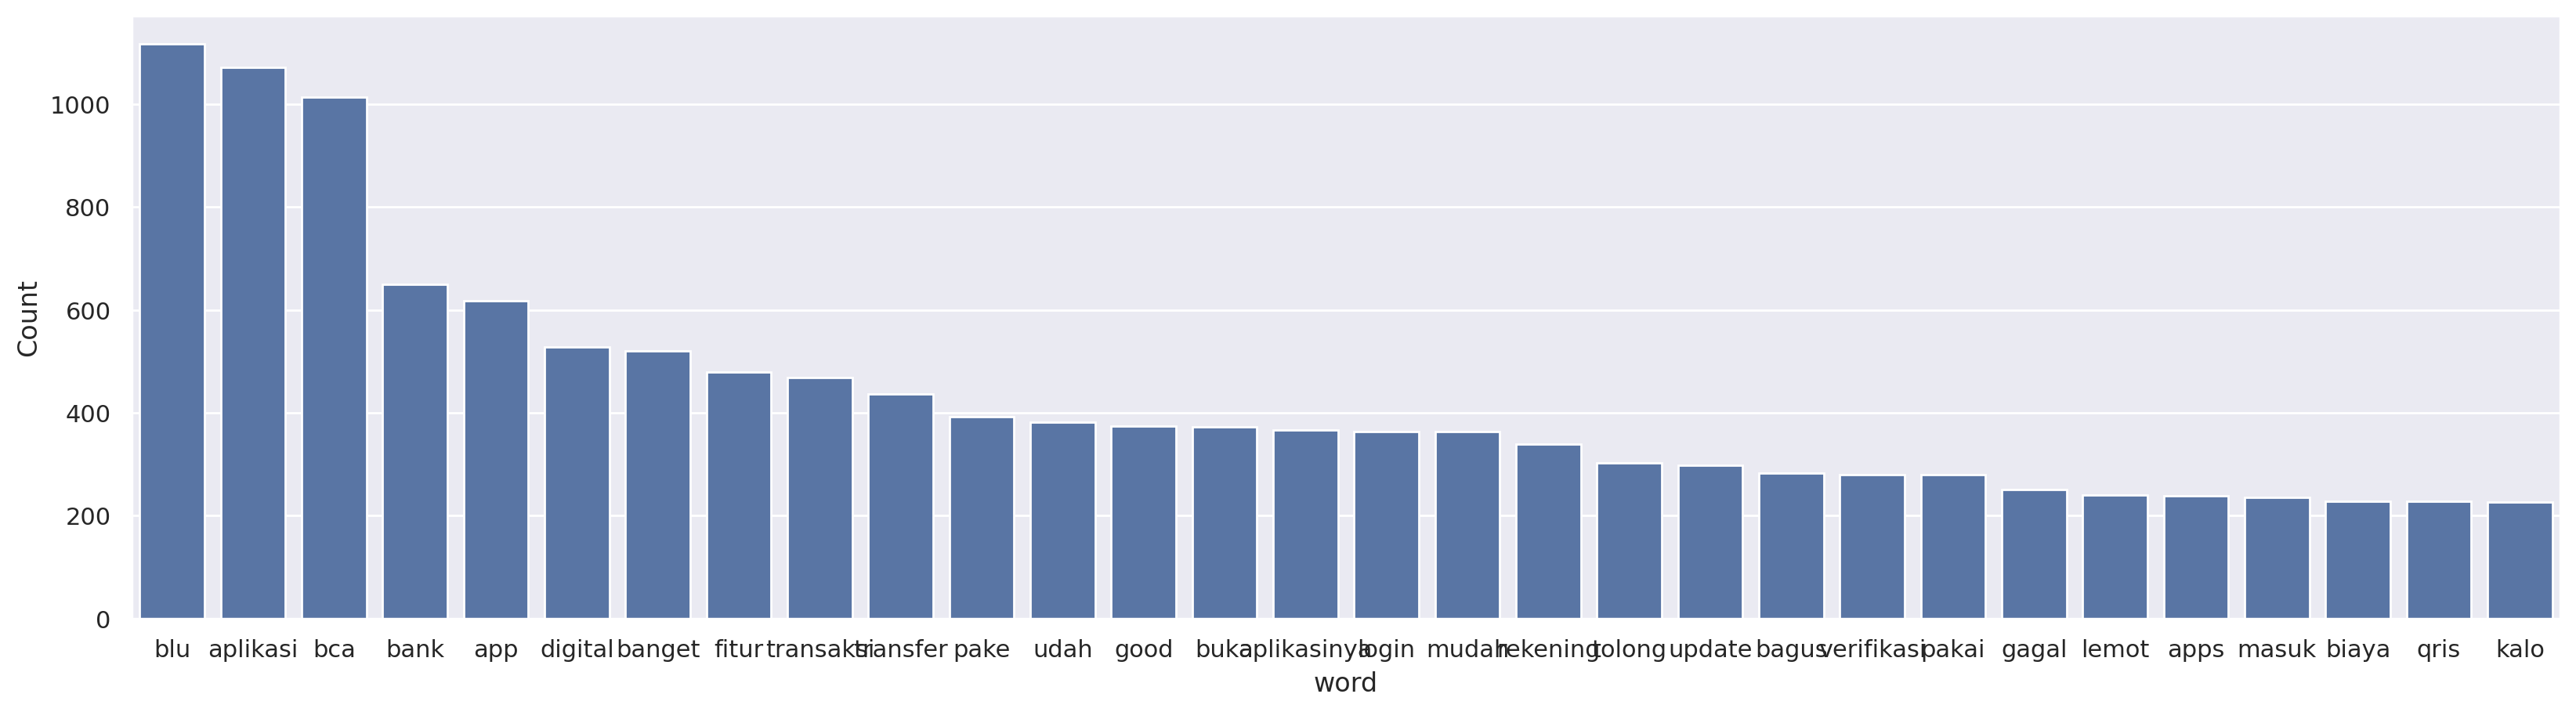

In [74]:
freq_words(df_bluRev_stopwords['review_without_stopwords'])

In [ ]:
newStopWords = ["'",".",",", "someone","still","would","need"]

#from nltk.corpus import stopwords
#stoplist = stopwords.words('english') + ['though']

#NOT YET DONE ==== 24 May 2022

In [77]:
#Stemming

#Stemming function chops off the end of the word
#and transform the word into its root form.
#All suffixes like -s, -es, -ed, -ing are removed.

def stemming(x):
    st = PorterStemmer()
    if x is not None:
        # Split the text, stem each word, and join them back
        return ' '.join([st.stem(word) for word in x.split()])
    return '' # Return an empty string if the input is None

df_bluRev_stopwords['review_without_stopwords'] = df_bluRev_stopwords['review_without_stopwords'].apply(lambda x:stemming(x))
print(df_bluRev_stopwords['review_without_stopwords'][9])

akhir2 app slow. forc close clear chace dipakai. bayar qr loadingnya lama, payment pakai aplikasi bank e-wallet lain, pakai blu 🥲


In [ ]:
#===BIGRAM https://towardsdatascience.com/text-analysis-basics-in-python-443282942ec5 not yet
#Creating bigram/trigram to search

In [78]:
#DROP NA
df_bluRev_stopwords.dropna(inplace=True)
df_bluRev_stopwords.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7502 entries, 0 to 7501
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   content                    7502 non-null   object 
 1   score                      7502 non-null   int64  
 2   sentiment_polarity         7502 non-null   float64
 3   sentiment_subjective       7502 non-null   float64
 4   sentiment_rating           7502 non-null   object 
 5   review_without_stopwords   7502 non-null   object 
 6   wordCount                  7502 non-null   int64  
 7   wordCount_after_stopwords  7502 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 469.0+ KB


In [79]:
df_bluRev_stopwords.loc[:,["content","score","sentiment_rating","wordCount","review_without_stopwords", "wordCount_after_stopwords"]]

,content,score,sentiment_rating,wordCount,review_without_stopwords,wordCount_after_stopwords
0,nice apps dr blu 👍,5,Positive,5,nice app dr blu 👍,5
1,always ask permission for location eventhough i already gave the permission. i use x9c honor. please repair.,2,Negative,17,alway ask permiss locat eventhough alreadi gave permission. use x9c honor. plea repair.,13
2,sering banget eror,3,Neutral,3,banget eror,2
3,"buset loading loginnya lama bener ,mau bayar jadi sulit",1,Negative,9,"buset load loginnya bener ,mau bayar sulit",7
4,"face recognition nya jelek. gagal terus, udah beberapa kali ganti device selalu ada masalah di login face recognition. kalau memang belum matang, lebih baik ada opsi lain untuk login. selain hubun...",2,Negative,35,"face recognit jelek. gagal terus, udah kali ganti devic login face recognition. matang, opsi login. hubungi haloblu berbayar",18
...,...,...,...,...,...,...
7497,100 penginstall pertama,5,Positive,3,100 penginst,2
7498,amazing...fiturnya dan gratis transfer dan topup,5,Positive,6,amazing...fiturnya grati transfer topup,4
7499,gak ada yang wah fiturnya biasa ajah sama kaya samping. gak ada yang membedakan.,3,Neutral,14,fiturnya ajah kaya samping. membedakan.,5
7500,"nitip, ntar review tan",5,Positive,4,"nitip, ntar review tan",4
